# About this notebook
This notebook focuses on **Vietnamese Sentiment Analysis** (Classifying text into `POS`, `NEG`, and `NEU`). It is structured into two main parts:
---
### Part 1: Finetuning PhoBERT model [move to Fine tuning](#part1)
* **Objective:** Fine-tune `vinai/phobert-base-v2` using a custom hybrid architecture (`HybridPhoBERTClassifier`) with a weighted loss function to handle class imbalance.
* **Text Preprocessing:** Utilizes `underthesea` for Vietnamese word segmentation.
* **Evaluation:** Models are evaluated on a validation split and zero-shot/tested on a part of the **VLSP2016 dataset** (test_phobert.csv).
---
### Part 2: Compare with other ML techinques/model [move to Compare](#part2)
Compare the fine-tuned PhoBERT model against other Machine Learning and Deep Learning approaches:
* **Traditional ML:** LinearSVC, Logistic Regression, Multinomial Naive Bayes (with TF-IDF).
* **Deep Learning:** BiLSTM + Attention.
* **Pre-trained:** `wonrax/phobert-base-vietnamese-sentiment`.

---
**Environment:** Runs on Google Colab.

---

<a name="part1"></a>
# 1. Fine tuning PhoBERT

In [ ]:
!pip install -q -U scikit-learn matplotlib seaborn transformers datasets accelerate underthesea

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 137.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 115.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 107.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.9 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 1. IMPORT
# ============================================================
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from underthesea import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

from transformers import (
    AutoTokenizer,
    AutoModel,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
    set_seed
)

from transformers.modeling_outputs import SequenceClassifierOutput
from datasets import Dataset

In [ ]:
# ============================================================
# 2. RANDOM SEED
# ============================================================
set_seed(42)

# ============================================================
# 3. LOAD DATA
# ============================================================
csv_path = "/content/train_phobert.csv"

df = pd.read_csv(csv_path)

print("===== 5 DÒNG ĐẦU =====")
print(df.head())

===== 5 DÒNG ĐẦU =====
                                                text label
0                              khổ nhất người có bầu   NEG
1  thầy cô hay quá đắt đỏ trong việc tài trợ cho ...   NEG
2   chưa giặt nên không biết có bị giãn nhiều không?   NEU
3  chất dai tới nỗi sợ béo thêm 1 2 kí nữa là níc...   NEU
4  tao cũng ho trật mẹ khớp vai mà đéo phải 1 lần...   NEG


In [ ]:
# ============================================================
# 4. CLEAN DATA
# ============================================================
df = df.dropna(subset=["text", "label"])

# normalize label
df["label"] = (
    df["label"]
    .astype(str)
    .str.upper()
    .str.strip()
)

# chỉ giữ label hợp lệ
valid_labels = ["NEG", "POS", "NEU"]
df = df[df["label"].isin(valid_labels)]

print("\n===== LABEL DISTRIBUTION =====")
print(df["label"].value_counts())


===== LABEL DISTRIBUTION =====
label
POS    13860
NEG    13252
NEU     3625
Name: count, dtype: int64


In [ ]:
# 5. PREPROCESS
# ============================================================
def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower().strip()

    # tokenize tiếng Việt
    text = word_tokenize(text, format="text")

    return text

df["clean_text"] = df["text"].apply(preprocess_text)

# ============================================================
# 6. LABEL MAP
# ============================================================
label_mapping = {
    "NEG": 0,
    "POS": 1,
    "NEU": 2
}

inverse_label_mapping = {
    0: "NEG",
    1: "POS",
    2: "NEU"
}

df["label_id"] = df["label"].map(label_mapping)

In [ ]:
# ============================================================
# 7. TRAIN VALID SPLIT
# ============================================================
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["clean_text"].tolist(),
    df["label_id"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df["label_id"]
)

print("\n===== DATA SPLIT =====")
print("Train:", len(train_texts))
print("Validation:", len(val_texts))


===== DATA SPLIT =====
Train: 24589
Validation: 6148


In [ ]:
# ============================================================
# 8. TOKENIZER
# ============================================================
model_name = "vinai/phobert-base-v2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

MAX_LEN = 128

def tokenize_function(texts, labels):

    encodings = tokenizer(
        texts,
        truncation=True,
        padding=False,   # dynamic padding
        max_length=MAX_LEN
    )

    encodings["labels"] = labels

    return Dataset.from_dict(encodings)

train_dataset = tokenize_function(train_texts, train_labels)
val_dataset = tokenize_function(val_texts, val_labels)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

In [ ]:
# ============================================================
# 9. METRICS
# ============================================================
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [ ]:
# ============================================================
# 10. CUSTOM PHOBERT MODEL
# ============================================================
class HybridPhoBERTClassifier(nn.Module):

    def __init__(self, model_name=model_name, num_labels=3):

        super().__init__()

        self.bert = AutoModel.from_pretrained(model_name)

        # freeze 6 layer đầu
        for layer in self.bert.encoder.layer[:6]:
            for param in layer.parameters():
                param.requires_grad = False

        self.dropout = nn.Dropout(0.3)

        self.classifier = nn.Sequential(
            nn.Linear(self.bert.config.hidden_size, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_labels)
        )

        # weighted loss chống imbalance
        weights = torch.tensor([1.0, 1.0, 3.0])

        self.loss_fn = nn.CrossEntropyLoss(weight=weights)

    def forward(
        self,
        input_ids,
        attention_mask=None,
        labels=None,
        **kwargs
    ):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # token đầu tiên <s>
        sentence_rep = outputs.last_hidden_state[:, 0]

        x = self.dropout(sentence_rep)

        logits = self.classifier(x)

        loss = None

        if labels is not None:

            if logits.device != self.loss_fn.weight.device:
                self.loss_fn.weight = self.loss_fn.weight.to(logits.device)

            loss = self.loss_fn(logits, labels)

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits
        )

model = HybridPhoBERTClassifier()

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# ============================================================
# 11. TRAINING ARGUMENTS
# ============================================================
training_args = TrainingArguments(

    output_dir="./phobert_results",

    # epochs
    num_train_epochs=8,

    # batch
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    # learning
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,

    # evaluate/save
    eval_strategy="epoch",
    save_strategy="epoch",

    # best model
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    greater_is_better=True,

    # logging
    logging_steps=50,
    report_to="none",

    # mixed precision
    fp16=torch.cuda.is_available(),

    seed=42
)

# ============================================================
# 12. TRAINER
# ============================================================
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    data_collator=data_collator,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

# ============================================================
# 13. TRAIN
# ============================================================
print("\n===== START TRAINING =====")

trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



===== START TRAINING =====


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.468683,0.441683,0.863045,0.811389,0.800155,0.829444
2,0.386919,0.439176,0.872316,0.824041,0.811328,0.844628
3,0.392620,0.428529,0.882726,0.838679,0.828298,0.852599
4,0.219976,0.522952,0.885979,0.841543,0.835200,0.848975
5,0.253151,0.610735,0.880612,0.836650,0.830416,0.844677
6,0.174638,0.721432,0.887118,0.841462,0.842336,0.840671


TrainOutput(global_step=9222, training_loss=0.34986568195290896, metrics={'train_runtime': 882.4168, 'train_samples_per_second': 222.924, 'train_steps_per_second': 13.934, 'total_flos': 0.0, 'train_loss': 0.34986568195290896, 'epoch': 6.0})

In [ ]:
# ============================================================
# 14. SAVE MODEL
# ============================================================

save_path = "./best_phobert_model"

trainer.save_model(save_path)

tokenizer.save_pretrained(save_path)

print("\nMODEL SAVED:", save_path)

# ============================================================
# SAVE .PTH
# ============================================================

pth_path = "/content/phobert_custom_model.pth"

clean_state_dict = {
    k: v
    for k, v in model.state_dict().items()
    if "loss_fn" not in k
}

torch.save(
    clean_state_dict,
    pth_path
)

print("\nPTH MODEL SAVED:", pth_path)


MODEL SAVED: ./best_phobert_model

PTH MODEL SAVED: /content/phobert_custom_model.pth



=====  EVALUATION =====


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.174638,0.522952,6,0.885979,0.841543,0.835200,0.848975


Accuracy : 0.8860
F1 Score : 0.8415
Precision: 0.8352
Recall   : 0.8490


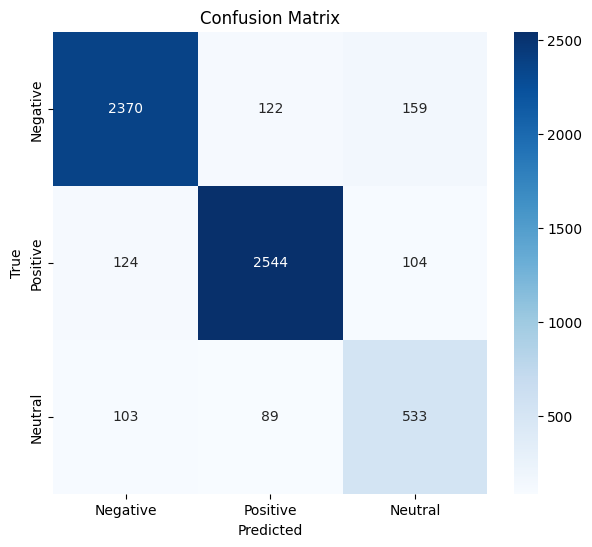


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    Negative     0.9126    0.8940    0.9032      2651
    Positive     0.9234    0.9177    0.9206      2772
     Neutral     0.6696    0.7352    0.7009       725

    accuracy                         0.8860      6148
   macro avg     0.8352    0.8490    0.8415      6148
weighted avg     0.8888    0.8860    0.8872      6148



In [ ]:
# ============================================================
# 15.  EVALUATION
# ============================================================
print("\n=====  EVALUATION =====")

final_metrics = trainer.evaluate()

print(f"Accuracy : {final_metrics['eval_accuracy']:.4f}")
print(f"F1 Score : {final_metrics['eval_f1']:.4f}")
print(f"Precision: {final_metrics['eval_precision']:.4f}")
print(f"Recall   : {final_metrics['eval_recall']:.4f}")

# ============================================================
# 16. CONFUSION MATRIX
# ============================================================
predictions_output = trainer.predict(val_dataset)

y_pred = np.argmax(
    predictions_output.predictions,
    axis=-1
)

y_true = val_labels

cm = confusion_matrix(y_true, y_pred)

target_names = [
    "Negative",
    "Positive",
    "Neutral"
]

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()
# ============================================================
# 17. CLASSIFICATION REPORT
# ============================================================
print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        digits=4
    )
)


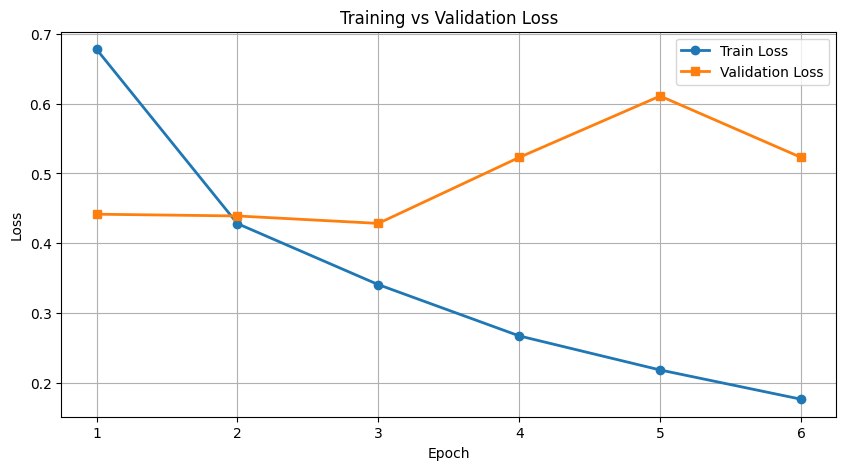

In [ ]:
# ============================================================
# 18. LOSS CURVE
# ============================================================

history = trainer.state.log_history

from collections import defaultdict
import numpy as np

# ============================================================
# TRAIN LOSS
# ============================================================

train_epoch_map = defaultdict(list)

for log in history:

    if (
        "loss" in log
        and "epoch" in log
        and "eval_loss" not in log
    ):

        epoch = int(np.ceil(log["epoch"]))

        train_epoch_map[epoch].append(log["loss"])

train_epochs = []
train_losses = []

for ep in sorted(train_epoch_map.keys()):

    train_epochs.append(ep)

    train_losses.append(
        np.mean(train_epoch_map[ep])
    )

# ============================================================
# VALIDATION LOSS
# ============================================================

val_loss_map = {}

for log in history:

    if "eval_loss" in log and "epoch" in log:

        epoch = int(log["epoch"])

        # overwrite để giữ log cuối cùng
        val_loss_map[epoch] = log["eval_loss"]

val_epochs = sorted(val_loss_map.keys())

val_losses = [
    val_loss_map[ep]
    for ep in val_epochs
]

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    train_epochs,
    train_losses,
    marker="o",
    linewidth=2,
    label="Train Loss"
)

plt.plot(
    val_epochs,
    val_losses,
    marker="s",
    linewidth=2,
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.xticks(val_epochs)

plt.grid(True)

plt.legend()

plt.show()

In [ ]:
# ============================================================
# 19. TEST ON VLSP
# ============================================================
print("\n===== LOAD TEST VLSP =====")

test_df = pd.read_csv("/content/vlsp_data.csv")

test_df = test_df.dropna(subset=["text", "label"])

# normalize
test_df["label"] = (
    test_df["label"]
    .astype(str)
    .str.upper()
    .str.strip()
)

test_df = test_df[
    test_df["label"].isin(valid_labels)
]

test_df["label_id"] = test_df["label"].map(label_mapping)

# preprocess
test_df["clean_text"] = test_df["text"].apply(preprocess_text)

test_texts = test_df["clean_text"].tolist()
test_labels = test_df["label_id"].tolist()

# tokenize
test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=False,
    max_length=MAX_LEN
)

test_encodings["labels"] = test_labels

test_dataset = Dataset.from_dict(test_encodings)

# predict
print("\n===== TESTING ON VLSP =====")

predictions = trainer.predict(test_dataset)

pred_labels = np.argmax(
    predictions.predictions,
    axis=-1
)

# metrics
acc = accuracy_score(test_labels, pred_labels)

f1 = precision_recall_fscore_support(
    test_labels,
    pred_labels,
    average="macro"
)[2]

print("\n===== TEST RESULT =====")

print(f"Accuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\n===== DETAILED REPORT =====")

print(
    classification_report(
        test_labels,
        pred_labels,
        target_names=target_names,
        digits=4
    )
)



===== LOAD TEST VLSP =====

===== TESTING ON VLSP =====



===== TEST RESULT =====
Accuracy : 0.7376
F1 Score : 0.7415

===== DETAILED REPORT =====
              precision    recall  f1-score   support

    Negative     0.8054    0.6865    0.7412      1700
    Positive     0.8601    0.7412    0.7962      1700
     Neutral     0.6107    0.7853    0.6871      1700

    accuracy                         0.7376      5100
   macro avg     0.7587    0.7376    0.7415      5100
weighted avg     0.7587    0.7376    0.7415      5100



In [ ]:
# Nén toàn bộ thư mục thành file 'ket_qua.zip'
!zip -r ket_qua.zip /content/best_phobert_model

  adding: content/best_phobert_model/ (stored 0%)
  adding: content/best_phobert_model/training_args.bin (deflated 53%)
  adding: content/best_phobert_model/tokenizer_config.json (deflated 77%)
  adding: content/best_phobert_model/vocab.txt (deflated 55%)
  adding: content/best_phobert_model/model.safetensors (deflated 7%)
  adding: content/best_phobert_model/bpe.codes (deflated 59%)
  adding: content/best_phobert_model/added_tokens.json (stored 0%)


<a name="part2"></a>
# 2. MODEL COMPARE

---
 - LinearSVC
 - Logistic Regression
 - Multinomial Naive Bayes
 - wonrax/phobert-base-vietnamese-sentiment
 - PhoBERT Custom
 - BiLSTM + Attention
 ### [Result and Chart](#result)


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from torch.utils.data import (
    Dataset as TorchDataset,
    DataLoader
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

In [ ]:
results = []

# ============================================================
# HELPER FUNCTION
# ============================================================

def evaluate_model(name, y_true, y_pred):

    acc = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    print("\n" + "="*70)
    print(name)
    print("="*70)

    print(f"Accuracy : {acc:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")

    print("\nCLASSIFICATION REPORT\n")

    print(
        classification_report(
            y_true,
            y_pred,
            digits=4
        )
    )

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "F1": round(f1, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4)
    })

In [ ]:
print("\n===== LOAD DATA =====")

df_train = pd.read_csv("/content/train_phobert.csv")
df_test = pd.read_csv("/content/test_phobert.csv")

# clean
df_train = df_train.dropna(subset=["text", "label"])
df_test = df_test.dropna(subset=["text", "label"])

# normalize label
df_train["label"] = (
    df_train["label"]
    .astype(str)
    .str.upper()
    .str.strip()
)

df_test["label"] = (
    df_test["label"]
    .astype(str)
    .str.upper()
    .str.strip()
)

valid_labels = ["NEG", "POS", "NEU"]

df_train = df_train[
    df_train["label"].isin(valid_labels)
]

df_test = df_test[
    df_test["label"].isin(valid_labels)
]


===== LOAD DATA =====


In [ ]:
# ============================================================
# PREPROCESS
# ============================================================

def preprocess_text(text):

    if not isinstance(text, str):
        return ""

    text = text.lower().strip()

    text = word_tokenize(
        text,
        format="text"
    )

    return text

df_train["clean_text"] = df_train["text"].apply(preprocess_text)
df_test["clean_text"] = df_test["text"].apply(preprocess_text)

X_train = df_train["clean_text"]
X_test = df_test["clean_text"]

y_train = df_train["label"]
y_test = df_test["label"]

In [ ]:
# ============================================================
# TF-IDF
# ============================================================

print("\n===== TF-IDF =====")

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000,
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Train shape:", X_train_tfidf.shape)
print("Test shape :", X_test_tfidf.shape)


===== TF-IDF =====
Train shape: (30737, 36366)
Test shape : (4080, 36366)


In [ ]:
# ============================================================
# 1. LINEAR SVC
# ============================================================

print("\n===== TRAIN LINEAR SVC =====")

svc_model = LinearSVC(
    class_weight="balanced",
    random_state=42,
    C=1.0
)

svc_model.fit(X_train_tfidf, y_train)

y_pred_svc = svc_model.predict(X_test_tfidf)

evaluate_model(
    "LinearSVC",
    y_test,
    y_pred_svc
)


===== TRAIN LINEAR SVC =====

LinearSVC
Accuracy : 0.6321
F1 Score : 0.6340
Precision: 0.6465
Recall   : 0.6321

CLASSIFICATION REPORT

              precision    recall  f1-score   support

         NEG     0.6256    0.6279    0.6268      1360
         NEU     0.5572    0.6765    0.6111      1360
         POS     0.7566    0.5919    0.6642      1360

    accuracy                         0.6321      4080
   macro avg     0.6465    0.6321    0.6340      4080
weighted avg     0.6465    0.6321    0.6340      4080



In [ ]:
# ============================================================
# 2. LOGISTIC REGRESSION
# ============================================================

print("\n===== TRAIN LOGISTIC REGRESSION =====")

lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr
)


===== TRAIN LOGISTIC REGRESSION =====

Logistic Regression
Accuracy : 0.5762
F1 Score : 0.5715
Precision: 0.6451
Recall   : 0.5762

CLASSIFICATION REPORT

              precision    recall  f1-score   support

         NEG     0.6536    0.4551    0.5366      1360
         NEU     0.4710    0.8235    0.5993      1360
         POS     0.8106    0.4500    0.5787      1360

    accuracy                         0.5762      4080
   macro avg     0.6451    0.5762    0.5715      4080
weighted avg     0.6451    0.5762    0.5715      4080



In [ ]:
# ============================================================
# 3. MULTINOMIAL NB
# ============================================================

print("\n===== TRAIN NAIVE BAYES =====")

nb_model = MultinomialNB(alpha=0.1)

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

evaluate_model(
    "Multinomial Naive Bayes",
    y_test,
    y_pred_nb
)


===== TRAIN NAIVE BAYES =====

Multinomial Naive Bayes
Accuracy : 0.5657
F1 Score : 0.5601
Precision: 0.6302
Recall   : 0.5657

CLASSIFICATION REPORT

              precision    recall  f1-score   support

         NEG     0.5620    0.5963    0.5787      1360
         NEU     0.4852    0.7243    0.5811      1360
         POS     0.8435    0.3765    0.5206      1360

    accuracy                         0.5657      4080
   macro avg     0.6302    0.5657    0.5601      4080
weighted avg     0.6302    0.5657    0.5601      4080



In [ ]:
# ============================================================
# 4. WONRAX PRETRAINED PHOBERT
# ============================================================

print("\n===== LOAD WONRAX MODEL =====")

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

wonrax_name = "wonrax/phobert-base-vietnamese-sentiment"

wonrax_tokenizer = AutoTokenizer.from_pretrained(
    wonrax_name,
    use_fast=False
)

wonrax_model = AutoModelForSequenceClassification.from_pretrained(
    wonrax_name
).to(device)

wonrax_model.eval()

# label map
wonrax_inverse_map = {
    0: "NEG",
    1: "POS",
    2: "NEU"
}

# predict
def predict_wonrax(texts, batch_size=32):

    preds_all = []

    for i in range(0, len(texts), batch_size):

        batch_texts = texts[i:i+batch_size]

        encodings = wonrax_tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=128,
            return_tensors="pt"
        )

        encodings = {
            k: v.to(device)
            for k, v in encodings.items()
        }

        with torch.no_grad():

            outputs = wonrax_model(**encodings)

            preds = torch.argmax(
                outputs.logits,
                dim=-1
            )

        preds = preds.cpu().numpy()

        preds_all.extend(preds)

    return preds_all

print("\n===== RUN WONRAX =====")

wonrax_pred_ids = predict_wonrax(
    X_test.tolist()
)

wonrax_preds = [
    wonrax_inverse_map[p]
    for p in wonrax_pred_ids
]

evaluate_model(
    "wonrax/phobert-base-vietnamese-sentiment",
    y_test,
    wonrax_preds
)


===== LOAD WONRAX MODEL =====


config.json:   0%|          | 0.00/999 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


===== RUN WONRAX =====


model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]


wonrax/phobert-base-vietnamese-sentiment
Accuracy : 0.6154
F1 Score : 0.5975
Precision: 0.6130
Recall   : 0.6154

CLASSIFICATION REPORT

              precision    recall  f1-score   support

         NEG     0.6711    0.6346    0.6523      1360
         NEU     0.5692    0.3507    0.4340      1360
         POS     0.5987    0.8610    0.7063      1360

    accuracy                         0.6154      4080
   macro avg     0.6130    0.6154    0.5975      4080
weighted avg     0.6130    0.6154    0.5975      4080



In [ ]:
# ============================================================
# 5. PHOBERT CUSTOM
# ============================================================

print("\n===== CUSTOM PHOBERT RESULT =====")

# ============================================================
# TOKENIZE TEST DATA
# ============================================================

test_texts = df_test["clean_text"].tolist()

test_labels = [
    label_mapping[label]
    for label in df_test["label"]
]

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=False,
    max_length=128
)

test_encodings["labels"] = test_labels

test_dataset = Dataset.from_dict(test_encodings)

# ============================================================
# PREDICT
# ============================================================

predictions_output = trainer.predict(test_dataset)

phobert_pred_ids = np.argmax(
    predictions_output.predictions,
    axis=-1
)

inverse_map = {
    0: "NEG",
    1: "POS",
    2: "NEU"
}

phobert_preds = [
    inverse_map[p]
    for p in phobert_pred_ids
]

y_true_phobert = [
    inverse_map[y]
    for y in test_labels
]

evaluate_model(
    "Custom PhoBERT",
    y_true_phobert,
    phobert_preds
)


===== CUSTOM PHOBERT RESULT =====



Custom PhoBERT
Accuracy : 0.7027
F1 Score : 0.7072
Precision: 0.7265
Recall   : 0.7027

CLASSIFICATION REPORT

              precision    recall  f1-score   support

         NEG     0.7702    0.6456    0.7024      1360
         NEU     0.5713    0.7478    0.6478      1360
         POS     0.8379    0.7147    0.7714      1360

    accuracy                         0.7027      4080
   macro avg     0.7265    0.7027    0.7072      4080
weighted avg     0.7265    0.7027    0.7072      4080



In [ ]:
# ============================================================
# 6. BUILD VOCAB FOR BILSTM
# ============================================================

print("\n===== BUILD VOCAB =====")

all_words = " ".join(
    X_train.values
).split()

vocab_counter = Counter(all_words)

MAX_VOCAB = 30000

vocab = {
    word: idx + 2
    for idx, (word, _) in enumerate(
        vocab_counter.most_common(MAX_VOCAB)
    )
}

vocab["<PAD>"] = 0
vocab["<UNK>"] = 1

print("Vocab size:", len(vocab))

# ============================================================
# TEXT TO SEQUENCE
# ============================================================

MAX_LEN = 128

def text_to_sequence(text):

    tokens = text.split()

    seq = [
        vocab.get(token, 1)
        for token in tokens[:MAX_LEN]
    ]

    if len(seq) < MAX_LEN:
        seq += [0] * (MAX_LEN - len(seq))

    return seq

X_train_seq = np.array([
    text_to_sequence(t)
    for t in X_train
])

X_test_seq = np.array([
    text_to_sequence(t)
    for t in X_test
])

# label map
label_map = {
    "NEG": 0,
    "POS": 1,
    "NEU": 2
}

inverse_label_map = {
    0: "NEG",
    1: "POS",
    2: "NEU"
}

y_train_seq = np.array([
    label_map[y]
    for y in y_train
])

y_test_seq = np.array([
    label_map[y]
    for y in y_test
])

# ============================================================
# DATASET
# ============================================================

class TextDataset(TorchDataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.long
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

train_loader = DataLoader(
    TextDataset(X_train_seq, y_train_seq),
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    TextDataset(X_test_seq, y_test_seq),
    batch_size=64,
    shuffle=False
)


===== BUILD VOCAB =====
Vocab size: 18547


In [ ]:
# ============================================================
# BILSTM + ATTENTION
# ============================================================

class BiLSTM_Attention(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim=128,
        hidden_dim=128,
        num_classes=3
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.attention_weight = nn.Parameter(
            torch.randn(hidden_dim * 2, 1)
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        emb = self.embedding(x)

        lstm_out, _ = self.lstm(emb)

        attn_scores = torch.matmul(
            lstm_out,
            self.attention_weight
        ).squeeze(-1)

        attn_weights = torch.softmax(
            attn_scores,
            dim=-1
        ).unsqueeze(-1)

        context = torch.sum(
            lstm_out * attn_weights,
            dim=1
        )

        logits = self.fc(context)

        return logits

# ============================================================
# INIT MODEL
# ============================================================

print("\n===== TRAIN BILSTM =====")

bilstm_model = BiLSTM_Attention(
    vocab_size=len(vocab)
).to(device)

weights = torch.tensor(
    [1.0, 1.0, 3.0],
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=weights
)

optimizer = optim.AdamW(
    bilstm_model.parameters(),
    lr=1e-3,
    weight_decay=0.01
)

# ============================================================
# TRAIN
# ============================================================

EPOCHS = 5

bilstm_model.train()

for epoch in range(EPOCHS):

    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = bilstm_model(X_batch)

        loss = criterion(
            logits,
            y_batch
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
        f" - Loss: {avg_loss:.4f}"
    )

# ============================================================
# EVALUATE BILSTM
# ============================================================

print("\n===== EVALUATE BILSTM =====")

bilstm_model.eval()

all_preds = []

with torch.no_grad():

    for X_batch, _ in test_loader:

        X_batch = X_batch.to(device)

        logits = bilstm_model(X_batch)

        preds = torch.argmax(
            logits,
            dim=-1
        ).cpu().numpy()

        all_preds.extend(preds)

bilstm_preds = [
    inverse_label_map[p]
    for p in all_preds
]

evaluate_model(
    "BiLSTM + Attention",
    y_test,
    bilstm_preds
)


===== TRAIN BILSTM =====
Epoch 1/5 - Loss: 0.7305
Epoch 2/5 - Loss: 0.5422
Epoch 3/5 - Loss: 0.4401
Epoch 4/5 - Loss: 0.3532
Epoch 5/5 - Loss: 0.2949

===== EVALUATE BILSTM =====

BiLSTM + Attention
Accuracy : 0.5669
F1 Score : 0.5649
Precision: 0.5880
Recall   : 0.5669

CLASSIFICATION REPORT

              precision    recall  f1-score   support

         NEG     0.5920    0.4471    0.5094      1360
         NEU     0.4906    0.7096    0.5801      1360
         POS     0.6814    0.5441    0.6051      1360

    accuracy                         0.5669      4080
   macro avg     0.5880    0.5669    0.5649      4080
weighted avg     0.5880    0.5669    0.5649      4080



<a name="result"></a>
## Final Result
- F1 barplot
- Acc barplot
- Heatmap

In [ ]:
# ============================================================
# FINAL COMPARISON TABLE
# ============================================================

print("\n===== FINAL COMPARISON =====")

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1",
    ascending=False
)

print(results_df)

# ============================================================
# SAVE CSV
# ============================================================

results_df.to_csv(
    "final_model_comparison.csv",
    index=False
)

print("\nSaved: final_model_comparison.csv")


===== FINAL COMPARISON =====
                                      Model  Accuracy      F1  Precision  \
4                            Custom PhoBERT    0.7027  0.7072     0.7265   
0                                 LinearSVC    0.6321  0.6340     0.6465   
3  wonrax/phobert-base-vietnamese-sentiment    0.6154  0.5975     0.6130   
1                       Logistic Regression    0.5762  0.5715     0.6451   
5                        BiLSTM + Attention    0.5669  0.5649     0.5880   
2                   Multinomial Naive Bayes    0.5657  0.5601     0.6302   

   Recall  
4  0.7027  
0  0.6321  
3  0.6154  
1  0.5762  
5  0.5669  
2  0.5657  

Saved: final_model_comparison.csv


/tmp/ipykernel_1881/2902031982.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


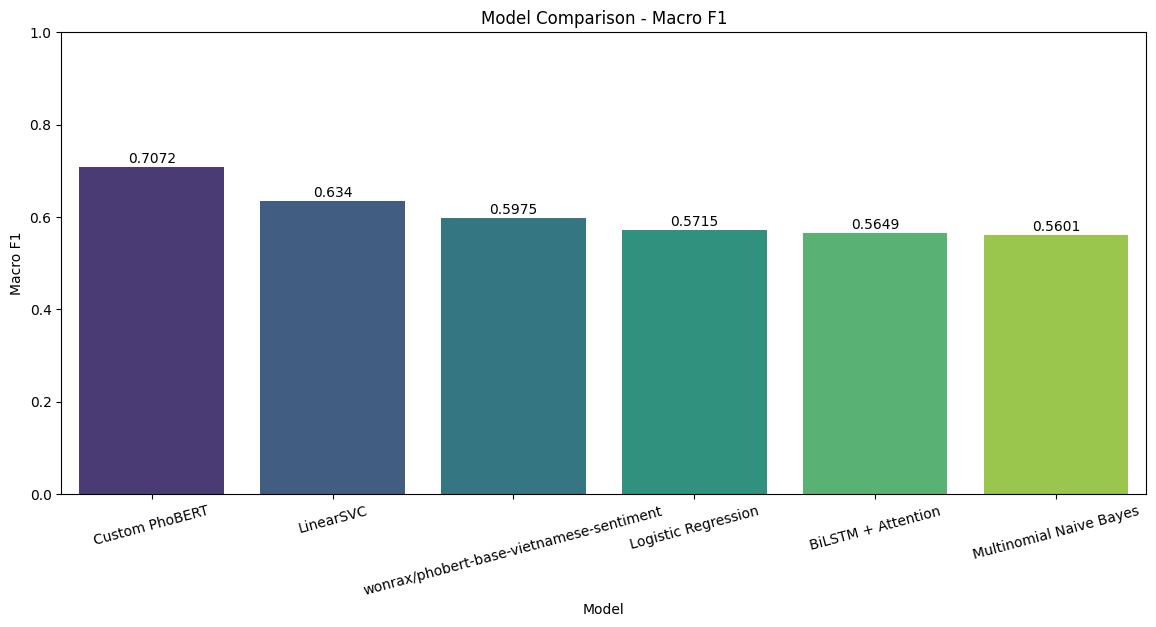

In [ ]:
# ============================================================
# F1 BARPLOT
# ============================================================

plt.figure(figsize=(14, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1",
    palette="viridis"
)

plt.title("Model Comparison - Macro F1")
plt.xlabel("Model")
plt.ylabel("Macro F1")

plt.xticks(rotation=15)

plt.ylim(0, 1)

for i, row in enumerate(results_df["F1"]):

    plt.text(
        i,
        row + 0.01,
        str(round(row, 4)),
        ha="center"
    )

plt.show()

/tmp/ipykernel_1881/1258188825.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


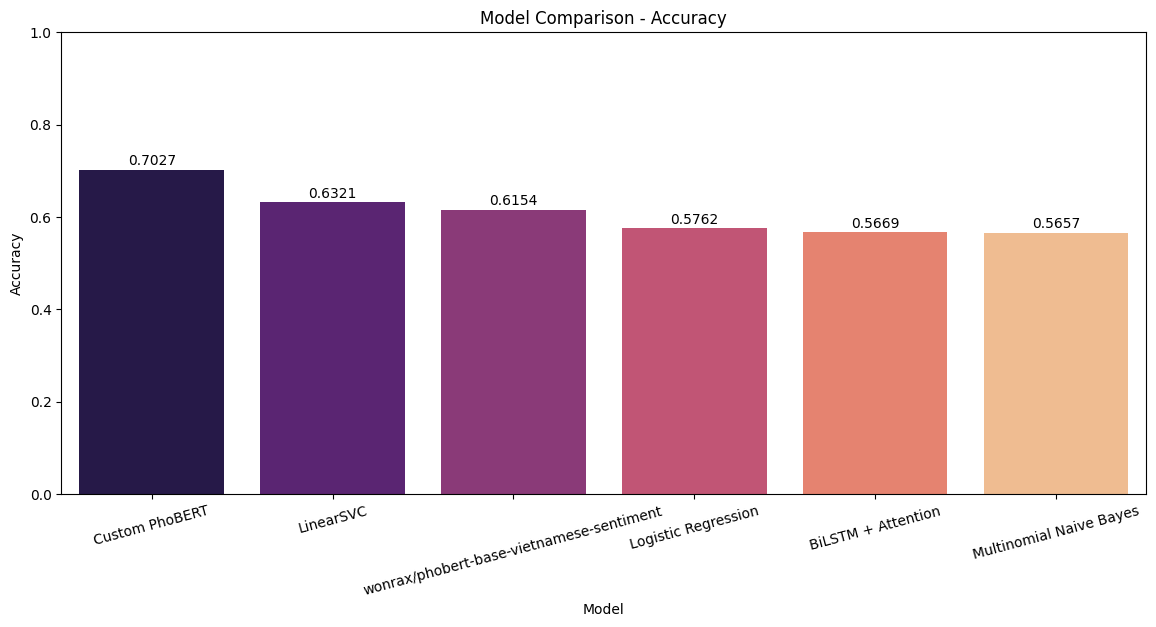

In [ ]:
# ============================================================
# ACCURACY BARPLOT
# ============================================================

plt.figure(figsize=(14, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    palette="magma"
)

plt.title("Model Comparison - Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.ylim(0, 1)

for i, row in enumerate(results_df["Accuracy"]):

    plt.text(
        i,
        row + 0.01,
        str(round(row, 4)),
        ha="center"
    )

plt.show()

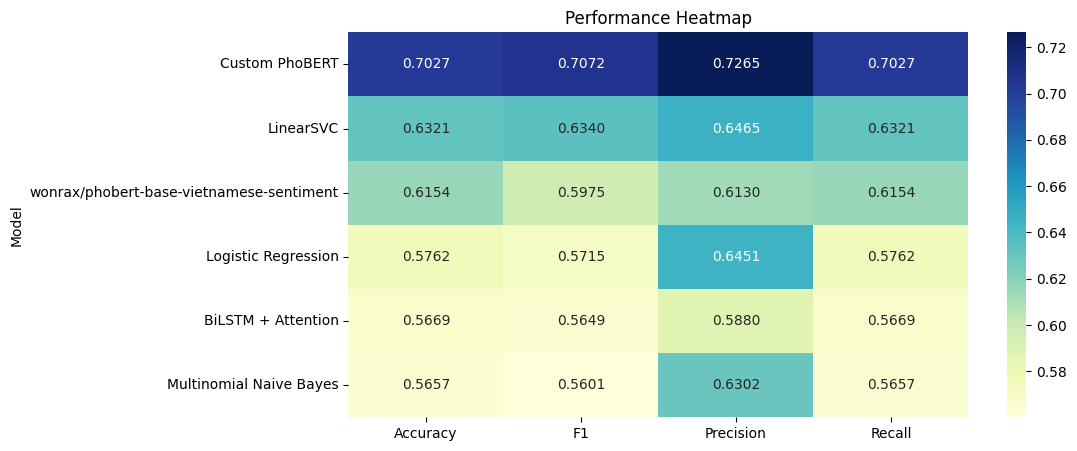


===== DONE =====


In [ ]:
# ============================================================
# HEATMAP COMPARISON
# ============================================================

plt.figure(figsize=(10, 5))

heatmap_df = results_df.set_index("Model")[
    ["Accuracy", "F1", "Precision", "Recall"]
]

sns.heatmap(
    heatmap_df,
    annot=True,
    cmap="YlGnBu",
    fmt=".4f"
)

plt.title("Performance Heatmap")

plt.show()

print("\n===== DONE =====")

# THE END.
# Thank you for looking into this experiment.